# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Seif Hesham  
**Student ID:** 1210244

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [3]:
# 1) Load dataset
df = pd.read_csv("kidney_disease.csv")

print("Original shape:", df.shape)

# Replace '?' with NaN 
df.replace("?", pd.NA, inplace=True)

# Convert all possible columns to numeric where applicable
for col in df.columns:
    if col != "classification":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 2) Separate target
y = df["classification"]
X = df.drop(columns=["classification"])

# Keep only numerical lab values
X_num = X.select_dtypes(include=["float64", "int64"]).copy()

print("Numerical features:", X_num.columns.tolist())
print("Numerical shape:", X_num.shape)

# 5) 80/20 train-validation split (LAB STYLE: before preprocessing)
X_train, X_val, y_train, y_val = train_test_split(
    X_num, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

# 3) Handle missing values (fit on TRAIN only)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)

# 4) Scale features (fit on TRAIN only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)

print("\n✓ Task 1 Data pipeline completed successfully")
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)

Original shape: (400, 26)
Numerical features: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Numerical shape: (400, 25)
Train shape: (320, 25)
Validation shape: (80, 25)

✓ Task 1 Data pipeline completed successfully
Scaled train shape: (320, 15)
Scaled validation shape: (80, 15)


d:\Apps\Python\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['rbc' 'pc' 'pcc' 'ba' 'htn' 'dm' 'cad' 'appet' 'pe' 'ane']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
d:\Apps\Python\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['rbc' 'pc' 'pcc' 'ba' 'htn' 'dm' 'cad' 'appet' 'pe' 'ane']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.8500 - loss: 0.4834 - val_accuracy: 1.0000 - val_loss: 0.1971
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9500 - loss: 0.1330 - val_accuracy: 1.0000 - val_loss: 0.0349
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9500 - loss: 0.0496 - val_accuracy: 0.9625 - val_loss: 0.0744
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0241 - val_accuracy: 1.0000 - val_loss: 0.0111
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 3.1046e-04 - val_accuracy: 1.0000 - val_loss: 0.0095
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 1.9225e-04 - val_accuracy: 0.9875 - 

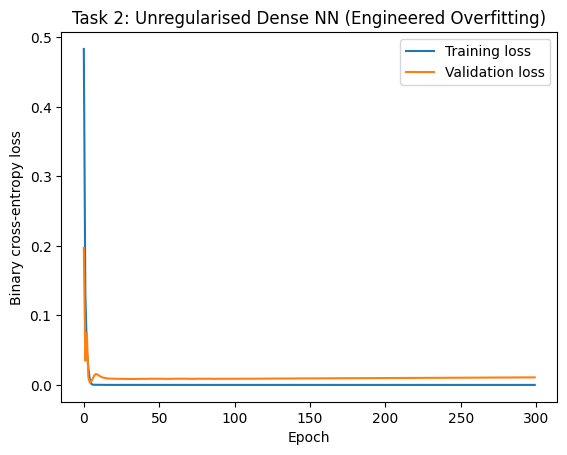

In [ ]:
from tensorflow.keras import layers, models

# 1) Encode labels (ckd=1, notckd=0)
y_train_bin = y_train.astype(str).str.strip().str.lower().map({"ckd": 1, "notckd": 0}).values.astype(np.float32)
y_val_bin   = y_val.astype(str).str.strip().str.lower().map({"ckd": 1, "notckd": 0}).values.astype(np.float32)

# 2) ENGINEERED FAILURE to force overfitting (small training subset)
X_train_small = X_train_scaled[:20]
y_train_small = y_train_bin[:20]

# 3) Unregularised Dense Network (no dropout, no L2, no early stopping)
tf.random.set_seed(42)

model = models.Sequential([
    tf.keras.layers.Input(shape=(X_train_small.shape[1],)),
    tf.keras.layers.Dense(1024, activation="relu"),
    tf.keras.layers.Dense(1024, activation="relu"),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_small, y_train_small,
    validation_data=(X_val_scaled, y_val_bin),
    epochs=400,
    batch_size=8,
    verbose=1
)

# 4) Plot training & validation loss (visual proof of overfitting)
plt.figure()
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Task 2: Unregularised Dense NN (Engineered Overfitting)")
plt.legend()
plt.show()

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

In [ ]:
# Write your Engineered Model code here


## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

In [ ]:
# Write your Evaluation code here


### Mathematical Justification
**Final Parameter Count of Engineered Model:** [Enter Number]

**Explanation:** [Write your one-sentence explanation here detailing why this parameter capacity and regularisation strategy mathematically prevents memorisation on a 400-patient dataset.]